# 设置环境变量

In [1]:
import getpass
import os

def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"请输入您的 {var}")

_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("TAVILY_API_KEY")

_set_if_undefined("DEEPSEEK_API_KEY")

# 工具实例化

In [2]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

tavily_tool = TavilySearch(max_results=5)

repl = PythonREPL()

@tool
def python_repl(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"


    return f"Successfully executed:\n```python\n{code}\n```\n"

/Users/elon/code/agents-bootcamp/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# 创建通用的agent node
    - 输入（状态流转信息，agent实例， agent的名字）
    - 输出（agent处理后的结果，处理者的名字）

In [23]:
import functools
from langchain_core.messages import AIMessage


def agent_node(state, agent, name):
    name = name.replace(" ", "_").replace("-", "_")
    result = agent.invoke(state)

    if isinstance(result, ToolMessage):
        pass
    else:
        payload = result.model_dump(exclude={"type", "name"})
        result = AIMessage(**payload, name=name)

    return {
        "messages": [result],
        "sender": name,
    }

# 创建一个通用的创建智能体调用方法

In [4]:
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import END, StateGraph, START

def create_agent(llm, tools, tool_message: str, custom_notice: str=""):
    """创建一个智能体。"""
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant, collaborating with other assistants."
                " Use the provided tools to progress towards answering the question."
                " If you are unable to fully answer, that's OK, another assistant with different tools "
                " will help where you left off. Execute what you can to make progress."
                " If you or any of the other assistants have the final answer or deliverable,"
                " prefix your response with FINAL ANSWER so the team knows to stop."
                "\n{custom_notice}\n"
                " You have access to the following tools: {tool_names}.\n{tool_message}\n\n",
            ),
            MessagesPlaceholder(variable_name="messages"),  

        ]
    )

    # 将系统消息部分和工具名称插入到提示模板中
    prompt = prompt.partial(tool_message=tool_message, custom_notice=custom_notice)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
      
    # 将提示模板与语言模型和工具绑定
    return prompt | llm.bind_tools(tools)

创建agent

In [ ]:
#from langchain_community.llms import ChatOpenAI
#research_llm = ChatOpenAI(model="gpt-4o-mini", timeout=30, max_retries=1)
#chart_llm = ChatOpenAI(model="gpt-4o-mini", timeout=30, max_retries=1)
from langchain_deepseek import ChatDeepSeek
research_llm = ChatDeepSeek(model="deepseek-chat")
chart_llm = ChatDeepSeek(model="deepseek-chat")


In [6]:
research_agent = create_agent(
    research_llm,
    [tavily_tool],
    tool_message=(
        "Before using the search engine, carefully think through and clarify the query."
        " Then, conduct a single search that addresses all aspects of the query in one go."
    ),
    custom_notice=(
        "Notice:\n"
        "Only gather and organize information. Do not generate code or give final conclusions, leave that for other assistants."
    ),
)

research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

In [ ]:
chart_agent = create_agent(
    chart_llm,  # 使用 chart_llm 作为图表生成器智能体的语言模型
    [python_repl],  # 图表生成器智能体使用 Python REPL 工具
    tool_message="Create clear and user-friendly charts based on the provided data.",  # 系统消息，指导智能体如何生成图表
    custom_notice="Notice:\n"
    "If you have completed all tasks, respond with FINAL ANSWER.",
)


chart_node = functools.partial(agent_node, agent=chart_agent, name="Chart_Generator")


创建工具节点

In [8]:
from langgraph.prebuilt import ToolNode

tools = [tavily_tool, python_repl]
tool_node = ToolNode(tools)

创建agent信息数据结构

In [9]:
import operator
from typing import Annotated, Sequence, TypedDict

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str

创建工作流，加入节点

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("Researcher", research_node)
workflow.add_node("Chart_Generator", chart_node)
workflow.add_node("call_tool", tool_node)

创建到工具节点的路由规则

In [ ]:
from typing import Literal

# 路由器函数，用于决定下一步是执行工具还是结束任务
def router(state) -> Literal["call_tool", "__end__", "continue"]:
    messages = state["messages"]
    last_message = messages[-1]

    # 优先处理工具调用
    if getattr(last_message, "tool_calls", None):
        return "call_tool"

    # 大小写不敏感，避免模型输出 Final answer / final answer 时无法结束
    content = (last_message.content or "") if hasattr(last_message, "content") else ""
    if "final answer" in content.lower():
        return "__end__"

    return "continue"

添加边

In [12]:
workflow.add_conditional_edges(
    "Researcher",
    router,  # 路由器函数决定下一步
    {
        "continue": "Chart_Generator",  # 如果 router 返回 "continue"，则传递到 Chart_Generator
        "call_tool": "call_tool",  # 如果 router 返回 "call_tool"，则调用工具
        "__end__": END  # 如果 router 返回 "__end__"，则结束工作流
    },
)

# 为 "Chart_Generator" 智能体节点添加条件边
workflow.add_conditional_edges(
    "Chart_Generator",
    router,  # 同样使用 router 函数决定下一步
    {
        "continue": "Researcher",  # 如果 router 返回 "continue"，则回到 Researcher
        "call_tool": "call_tool",  # 如果 router 返回 "call_tool"，则调用工具
        "__end__": END  # 如果 router 返回 "__end__"，则结束工作流
    },
)

# 为 "call_tool" 工具节点添加条件边，基于“sender”字段决定下一个节点
# 工具调用节点不更新 sender 字段，这意味着边将返回给调用工具的智能体
workflow.add_conditional_edges(
    "call_tool",
    lambda x: x["sender"],  # 根据 sender 字段判断调用工具的是哪个智能体
    {
        "Researcher": "Researcher",  # 如果 sender 是 Researcher，则返回给 Researcher
        "Chart_Generator": "Chart_Generator",  # 如果 sender 是 Chart_Generator，则返回给 Chart_Generator
    },
)


编译

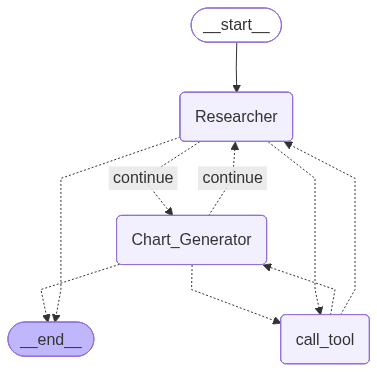

In [13]:
workflow.add_edge(START, "Researcher")
graph = workflow.compile()

from IPython.display import Image, display

try:
    display(
        Image(
            graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

启动

================================ Human Message =================================

Obtain the GDP of the United States from 2020 to 2025, and then plot a line chart with Python. End the task after generating the chart.


/var/folders/cn/6c876t4s0r551q74shgsp5lm0000gn/T/ipykernel_25267/2009902945.py:11: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


================================== Ai Message ==================================
Name: Researcher

I'll help you gather the GDP data for the United States from 2020 to 2025. Let me search for this information.
Tool Calls:
  tavily_search (call_00_LwzrKWHARrqilednQfm0NQQD)
 Call ID: call_00_LwzrKWHARrqilednQfm0NQQD
  Args:
    query: United States GDP 2020 2021 2022 2023 2024 2025 actual forecast data
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "United States GDP 2020 2021 2022 2023 2024 2025 actual forecast data", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://tradingeconomics.com/united-states/gdp-growth", "title": "United States GDP Growth Rate", "content": "The US economy expanded an annualized 1.4% in Q4 2025, the least since Q1 2025, following a 4.4% growth in Q3 and well below forecasts of 3%, the advance estimate showed. Consumer spending slowed

/var/folders/cn/6c876t4s0r551q74shgsp5lm0000gn/T/ipykernel_25267/2009902945.py:11: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


================================== Ai Message ==================================
Name: Researcher

Now let me search for more specific GDP data including the actual dollar amounts for each year from 2020 to 2025.
Tool Calls:
  tavily_search (call_00_ZB3IYaeuhB9WkfPmdGw6OhUs)
 Call ID: call_00_ZB3IYaeuhB9WkfPmdGw6OhUs
  Args:
    query: United States GDP nominal dollars 2020 2021 2022 2023 2024 2025 in trillions
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "United States GDP nominal dollars 2020 2021 2022 2023 2024 2025 in trillions", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.multpl.com/us-gdp/table/by-year", "title": "US GDP by Year - Multpl", "content": "| Date | Value |\n --- |\n| Sep 30, 2025 | 31.10 trillion |\n| Dec 31, 2024 | 29.83 trillion |\n| Dec 31, 2023 | 28.42 trillion |\n| Dec 31, 2022 | 26.77 trillion |\n| Dec 31, 2021 | 24.81 tri

...

================================== Ai Message ==================================
Name: Researcher

Let me search for a comprehensive table of U.S. GDP annual data from 2020 to 2025.
Tool Calls:
  tavily_search (call_00_d07QMGNWzBPJ3468hnIWQoZF)
 Call ID: call_00_d07QMGNWzBPJ3468hnIWQoZF
  Args:
    query: "U.S. GDP" "2020" "2021" "2022" "2023" "2024" "2025" annual data table
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "U.S. GDP 2020 2021 2022 2023 2024 2025 annual data table", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://tradingeconomics.com/united-states/gdp-growth-annual", "title": "United States GDP Annual Growth Rate - Trading Economics", "content": "The US economy expanded 2.2% year-on-year in the fourth quarter of 2025, slightly below the previous period's growth of 2.3%. GDP Annual Growth Rate in the United States averaged 3.15 percent from 19

/var/folders/cn/6c876t4s0r551q74shgsp5lm0000gn/T/ipykernel_25267/2009902945.py:11: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


================================== Ai Message ==================================
Name: Researcher

Based on my research, I have gathered comprehensive GDP data for the United States from 2020 to 2025. Let me organize this information for you:

## U.S. GDP Data (2020-2025)

From multiple sources including the U.S. Bureau of Economic Analysis (BEA), World Bank, and Macrotrends, here's the annual nominal GDP data for the United States:

**2020:** $21.354 trillion (Macrotrends) / $22.09 trillion (Multpl)
- Note: 2020 saw a 0.86% decline from 2019 due to the COVID-19 pandemic

**2021:** $23.681 trillion (Macrotrends) / $24.81 trillion (Multpl)
- 10.9% increase from 2020

**2022:** $26.007 trillion (Macrotrends) / $26.77 trillion (Multpl)
- 9.82% increase from 2021

**2023:** $27.721 trillion (Macrotrends) / $28.42 trillion (Multpl)
- 6.59% increase from 2022

**2024:** $29.18489 trillion (World Bank/Trading Economics) / $29.83 trillion (Multpl)
- Latest official data from World Bank

**2025

/var/folders/cn/6c876t4s0r551q74shgsp5lm0000gn/T/ipykernel_25267/2009902945.py:11: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)
Python REPL can execute arbitrary code. Use with caution.


================================== Ai Message ==================================
Name: Chart_Generator

I'll create a line chart showing the GDP of the United States from 2020 to 2025 using the data I've gathered. Let me use the consistent dataset from Macrotrends and World Bank for the plot.
Tool Calls:
  python_repl (call_00_vu402yC2fR43gfU0YjZ2OOTZ)
 Call ID: call_00_vu402yC2fR43gfU0YjZ2OOTZ
  Args:
    code: import matplotlib.pyplot as plt
import numpy as np

# Data for U.S. GDP from 2020 to 2025 (in trillions of USD)
# Using consistent data from Macrotrends and World Bank
years = [2020, 2021, 2022, 2023, 2024, 2025]
gdp_data = [21.354, 23.681, 26.007, 27.721, 29.185, 31.10]  # in trillions

# Calculate year-over-year growth rates
growth_rates = []
for i in range(1, len(gdp_data)):
    growth_rate = ((gdp_data[i] - gdp_data[i-1]) / gdp_data[i-1]) * 100
    growth_rates.append(growth_rate)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# P

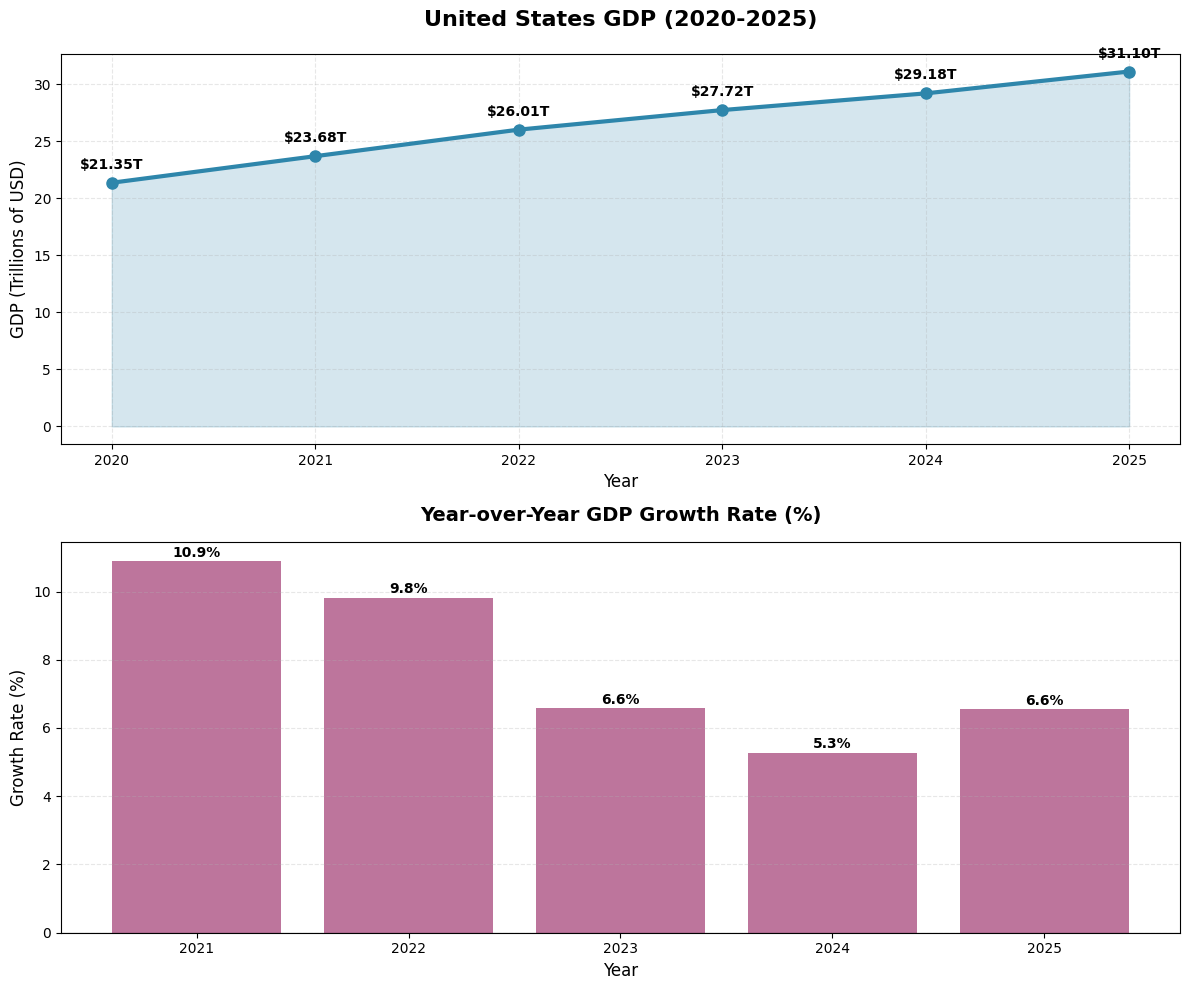

================================= Tool Message =================================
Name: python_repl

Successfully executed:
```python
import matplotlib.pyplot as plt
import numpy as np

# Data for U.S. GDP from 2020 to 2025 (in trillions of USD)
# Using consistent data from Macrotrends and World Bank
years = [2020, 2021, 2022, 2023, 2024, 2025]
gdp_data = [21.354, 23.681, 26.007, 27.721, 29.185, 31.10]  # in trillions

# Calculate year-over-year growth rates
growth_rates = []
for i in range(1, len(gdp_data)):
    growth_rate = ((gdp_data[i] - gdp_data[i-1]) / gdp_data[i-1]) * 100
    growth_rates.append(growth_rate)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: GDP Line Chart
ax1.plot(years, gdp_data, marker='o', linewidth=3, markersize=8, color='#2E86AB')
ax1.set_title('United States GDP (2020-2025)', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('GDP (Trillions of USD)', fontsize=12)
ax

/var/folders/cn/6c876t4s0r551q74shgsp5lm0000gn/T/ipykernel_25267/2009902945.py:11: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


In [ ]:
query = (
    "Obtain the GDP of the United States from 2020 to 2025, "
    "and then plot a line chart with Python. End the task after generating the chart."
)


events = graph.stream(
    {
        "messages": [HumanMessage(content=query)],
    },
    {"recursion_limit": 20},
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()


## 任务1：使用不同大模型运行多智能体并对比结果

In [35]:
from langchain_openai import ChatOpenAI
reasoner_llm = ChatOpenAI(model="gpt-4o-mini")

gpt_research_agent = create_agent(
    reasoner_llm,
    [tavily_tool],
    tool_message=(
        "Before using the search engine, carefully think through and clarify the query."
        " Then, conduct a single search that addresses all aspects of the query in one go."
    ),
    custom_notice=(
        "Notice:\n"
        "Only gather and organize information. Do not generate code or give final conclusions, leave that for other assistants."
    ),
)

reasoner_research_node = functools.partial(agent_node, agent=gpt_research_agent, name="GPT_Researcher")

gpt_chart_agent = create_agent(
    reasoner_llm,  
    [python_repl],  
    tool_message="Create clear and user-friendly charts based on the provided data.",  
    custom_notice="Notice:\n"
    "If you have completed all tasks, respond with FINAL ANSWER.",
)


gpt_chart_node = functools.partial(agent_node, agent=gpt_chart_agent, name="GPT_Chart_Generator")

gpt_workflow = StateGraph(AgentState)

gpt_workflow.add_node("GPT_Researcher", reasoner_research_node)
gpt_workflow.add_node("GPT_Chart_Generator", gpt_chart_node)
gpt_workflow.add_node("GPT_call_tool", tool_node)

gpt_workflow.add_conditional_edges(
    "GPT_Researcher",
    router,
    {
        "continue": "GPT_Chart_Generator",
        "call_tool": "GPT_call_tool",
        "__end__": END
    },
)

gpt_workflow.add_conditional_edges(
    "GPT_Chart_Generator",
    router,
    {
        "continue": "GPT_Researcher",
        "call_tool": "GPT_call_tool",
        "__end__": END
    },
)

gpt_workflow.add_conditional_edges(
    "GPT_call_tool",
    lambda x: x["sender"],
    {
        "GPT_Researcher": "GPT_Researcher",
        "GPT_Chart_Generator": "GPT_Chart_Generator",
    },
)

gpt_workflow.add_edge(START, "GPT_Researcher")

gpt_graph = gpt_workflow.compile()
events = gpt_graph.stream(
    {
        "messages": [HumanMessage(content=query)],
    },
    {"recursion_limit": 20},
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()



================================ Human Message =================================

Obtain the GDP of the United States from 2020 to 2025, and then plot a line chart with Python. End the task after generating the chart.


KeyboardInterrupt: 

## 任务2：将 Chart_Generator 替换为 table_generator 并运行查看结果

In [30]:
table_agent = create_agent(
    chart_llm,
    [python_repl],
    tool_message="Create clear and user-friendly markdown table based on the provided data.",  
    custom_notice="Notice:\n"
    "If you have completed all tasks, respond with FINAL ANSWER.",
)

table_node = functools.partial(agent_node, agent=table_agent, name="Table_Generator")

new_workflow = StateGraph(AgentState)
new_workflow.add_node("Researcher", research_node)
new_workflow.add_node("Table_Generator", table_node)
new_workflow.add_node("call_tool", tool_node)

new_workflow.add_conditional_edges(
    "Researcher",
    router,  
    {
        "continue": "Table_Generator", 
        "call_tool": "call_tool",  
        "__end__": END  
    },
)

new_workflow.add_conditional_edges(
    "Table_Generator",
    router,  
    {
        "continue": "Researcher",  
        "call_tool": "call_tool", 
        "__end__": END 
    },
)

new_workflow.add_conditional_edges(
    "call_tool",
    lambda x: x["sender"],  
    {
        "Researcher": "Researcher",  
        "Table_Generator": "Table_Generator", }
)

new_workflow.add_edge(START, "Researcher")
new_graph = new_workflow.compile()


table_query = (
    "Obtain the GDP of the United States from 2020 to 2025. "
    "Create a markdown table with columns: Year, GDP(USD Trillion), YoY(%). "
    "Explain data source briefly and end with FINAL ANSWER."
)

events = new_graph.stream(
    {
        "messages": [HumanMessage(content=table_query)],
    },
    {"recursion_limit": 20},
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

Obtain the GDP of the United States from 2020 to 2025. Create a markdown table with columns: Year, GDP(USD Trillion), YoY(%). Explain data source briefly and end with FINAL ANSWER.


/var/folders/cn/6c876t4s0r551q74shgsp5lm0000gn/T/ipykernel_25267/2009902945.py:11: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


================================== Ai Message ==================================
Name: Researcher

I'll search for the GDP data of the United States from 2020 to 2025, including both actual figures and projections where available.
Tool Calls:
  tavily_search (call_00_HnTHWdmq2RGq4wbvOo74VZj2)
 Call ID: call_00_HnTHWdmq2RGq4wbvOo74VZj2
  Args:
    query: United States GDP 2020 2021 2022 2023 2024 2025 actual figures projections USD trillion
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "United States GDP 2020 2021 2022 2023 2024 2025 actual figures projections USD trillion", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.macrotrends.net/global-metrics/countries/usa/united-states/gdp-gross-domestic-product", "title": "U.S. GDP | Historical Chart & Data - Macrotrends", "content": "U.S. GDP | Historical Chart & Data\n\n1/1 Skip Ad Continue watching after

/var/folders/cn/6c876t4s0r551q74shgsp5lm0000gn/T/ipykernel_25267/2009902945.py:11: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


================================== Ai Message ==================================
Name: Researcher

Now let me search for more specific GDP projections for 2024 and 2025, as well as get the exact figures for 2020-2023.
Tool Calls:
  tavily_search (call_00_7BwPTT2cOFfXFNmwRaIzNI7W)
 Call ID: call_00_7BwPTT2cOFfXFNmwRaIzNI7W
  Args:
    query: "U.S. GDP" 2024 2025 projections forecast World Bank IMF Federal Reserve
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "U.S. GDP 2024 2025 projections forecast World Bank IMF Federal Reserve", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://thedocs.worldbank.org/en/doc/8bf0b62ec6bcb886d97295ad930059e9-0050012025/original/GEP-June-2025.pdf", "title": "[PDF] Global Economic Prospects -- June 2025", "content": "and Song (2025); IMF Coordinated Direct Investment Survey (database); Ohnsorge, Stocker, and Some (2016); Uppsal

...

/var/folders/cn/6c876t4s0r551q74shgsp5lm0000gn/T/ipykernel_25267/2009902945.py:11: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


================================== Ai Message ==================================
Name: Researcher

Now let me search for the specific 2024 and 2025 GDP figures and projections.
Tool Calls:
  tavily_search (call_00_2lVLocwdUSGRIgD0DS7s0zLD)
 Call ID: call_00_2lVLocwdUSGRIgD0DS7s0zLD
  Args:
    query: "U.S. GDP" 2024 28.75 trillion 2025 projection forecast 29.2 29.5 trillion
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "U.S. GDP 2024 28.75 trillion 2025 projection forecast 29.2 29.5 trillion", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bea.gov/data/gdp/gross-domestic-product", "title": "Gross Domestic Product | U.S. Bureau of Economic Analysis (BEA)", "content": "### Current Release\n\n#### GDP (Advance Estimate), 4th Quarter and Year 2025\n\n- Full Release & Tables (PDF)\n- Tables Only (Excel)\n- Historical Comparisons (PDF)\n- Vintage History (

/var/folders/cn/6c876t4s0r551q74shgsp5lm0000gn/T/ipykernel_25267/2009902945.py:11: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


================================== Ai Message ==================================
Name: Researcher

Let me search for the World Bank data specifically for 2024 GDP and 2025 projections.
Tool Calls:
  tavily_search (call_00_NO7S9tevoU2cUwtlkyHsePiy)
 Call ID: call_00_NO7S9tevoU2cUwtlkyHsePiy
  Args:
    query: World Bank "United States GDP" 2024 28.75 trillion 2025 projection 29.2 trillion
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "World Bank United States GDP 2024 28.75 trillion 2025 projection 29.2 trillion", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://thedocs.worldbank.org/en/doc/8bf0b62ec6bcb886d97295ad930059e9-0050012025/original/GEP-June-2025.pdf", "title": "[PDF] Global Economic Prospects -- June 2025 - The World Bank", "content": "and Song (2025); IMF Coordinated Direct Investment Survey (database); Ohnsorge, Stocker, and Some (2016); Uppsal

/var/folders/cn/6c876t4s0r551q74shgsp5lm0000gn/T/ipykernel_25267/2009902945.py:11: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)
